# Label Density at Latent Space

用来比较不同active learning的sampling策略在latent space的label density
目标是证明entropy的策略能保证每种activity差不多密度

In [1]:
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

import torch.nn as nn
# from sklearn.model_selection import train_test_split
import torch
import pickle
from torch import optim
from torch.utils.data import DataLoader
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from deepview.calculate_results.models.utils import (
    label_colors,
    labeldict_findstr,
    # find_majority_minority,
    data_loader_umineko,
    AE_eval_time_series,
    majority_value,
    # sliding_window,
    # read_sensor_data,
    # process_acc,
    # process_acc_press,
    # process_acc_temperature,
    # process_acc_gyr,
    # process_press_temperature
)
# from deepview.calculate_results.data.umineko.train_func import (
#     train_model,
#     evaluate_model,
#     evaluate_supContrast_model,
#     plot_confusion_matrix,
#     unfreeze_encoders,
#     freeze_encoders,
#     unfreeze_all,
# )
from deepview.calculate_results.data.umineko.model_func import (
    SimpleNN_1s,
    SimpleNN_13s,
    SimpleNN_11s,
    SimpleNN_33s,
    ContrastiveLoss,
    SupContrastiveLoss,
)
# from deepview.calculate_results.data.umineko.active_utils import (
#     data_sampling
# )
# from deepview.calculate_results.data.umineko.cluster_method import (
#     # vis_scatter_label_2d,
#     plot_scatter_umi
# )
import plotly.express as px

In [2]:
root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'

def load_data(file_name):
    with open(os.path.join(root_path, file_name), 'rb') as f:
        data = pickle.load(f)
    return data

# ======= 1. 数据生成 ======= #
# active learning采用random sampling方法
file_name = 'AccelTemp__random_Contrast1_warm20_epoch20_results.pkl'  
result_dict = load_data(file_name)
base_acc = result_dict['test_micro_f1_list']
base_pred_label_lists = result_dict['test_pred_label_lists']
base_true_label_lists = result_dict['test_truth_label_lists']
base_selected_labels_list = result_dict['selected_labels_list']
base_ari_list = result_dict['ari_list']
base_nmi_list = result_dict['nmi_list']
base_fmi_list = result_dict['fmi_list']
base_silhouette_list = result_dict['silhouette_list']
base_label_data_list = result_dict['label_data_list']
base_unlabel_data_list = result_dict['unlabel_data_list']
base_weight_list = result_dict['weight_list']

file_name = 'AccelTemp__entropy_Contrast1_warm20_epoch20_results.pkl'  # noSupCont, only entropy active learning
result_dict = load_data(file_name)
entropy_acc = result_dict['test_micro_f1_list']
entropy_pred_label_lists = result_dict['test_pred_label_lists']
entropy_true_label_lists = result_dict['test_truth_label_lists']
entropy_selected_labels_list = result_dict['selected_labels_list']
entropy_ari_list = result_dict['ari_list']
entropy_nmi_list = result_dict['nmi_list']
entropy_fmi_list = result_dict['fmi_list']
entropy_silhouette_list = result_dict['silhouette_list']
entropy_label_data_list = result_dict['label_data_list']
entropy_unlabel_data_list = result_dict['unlabel_data_list']
entropy_weight_list = result_dict['weight_list']



D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\torch\storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


In [57]:
# sensor_type = 'Accel'
# sensor_type = 'AccelPress'
sensor_type = 'AccelTemp'
# sensor_type = 'AccelGyro'
# sensor_type = 'PressTemp'
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

# sampling_method = 'entropy'
# sampling_method = 'overAugment'
# sampling_method = 'underRandom'
sampling_method = 'random'
SupCount = 1  # supcontrastive learning
warmup = 20  # warmup epoch of supcontrastive learning
name_label = '_%s_Contrast%s_warm%s'%(sampling_method, str(SupCount), str(warmup))
# name_label = '_entropy_Contrast%s_freeze%s'%(str(SupCount), str(warmup))

iteration = 5  # 初始随机label后的第一次active annotation

len_sw = 50

In [58]:
# ======= 5. 循环主动学习 ======= #
# 初始化模型和优化器
if (sensor_type == 'Accel'):
    model = SimpleNN_1s()
elif (sensor_type == 'AccelPress') or (sensor_type == 'AccelTemp'):
    model = SimpleNN_13s()
elif (sensor_type == 'AccelGyro'):
    model = SimpleNN_33s()
elif (sensor_type == 'PressTemp'):
    model = SimpleNN_11s()
else:
    print('no model available')

In [59]:

model = model.to(device)
classify_criterion = nn.CrossEntropyLoss()
Contrast_criterion = ContrastiveLoss()
supContrast_criterion = SupContrastiveLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)


if sampling_method == 'entropy':
    label_data_list = entropy_label_data_list[iteration+1]
    selectlabel_data_list = entropy_selected_labels_list[iteration]
    unlabel_data_list = entropy_unlabel_data_list[iteration+1]
    weight_list = entropy_weight_list[iteration]
    pred_label_list = entropy_pred_label_lists[iteration]
    true_label_list = entropy_true_label_lists[iteration]
# elif sampling_method == 'overAugment':
#     label_data_list = over_label_data_list[iteration+1]
#     selectlabel_data_list = over_selected_labels_list[iteration]
#     unlabel_data_list = over_unlabel_data_list[iteration+1]
#     weight_list = over_weight_list[iteration]
#     pred_label_list = over_pred_label_lists[iteration]
#     true_label_list = over_true_label_lists[iteration]
# elif sampling_method == 'underRandom':
#     label_data_list = under_label_data_list[iteration+1]
#     selectlabel_data_list = under_selected_labels_list[iteration]
#     unlabel_data_list = under_unlabel_data_list[iteration+1]
#     weight_list = under_weight_list[iteration]
#     pred_label_list = under_pred_label_lists[iteration]
#     true_label_list = under_true_label_lists[iteration]
elif sampling_method == 'random':
    label_data_list = base_label_data_list[iteration+1]
    selectlabel_data_list = base_selected_labels_list[iteration]
    unlabel_data_list = base_unlabel_data_list[iteration+1]
    weight_list = base_weight_list[iteration]
    pred_label_list = base_pred_label_lists[iteration]
    true_label_list = base_true_label_lists[iteration]
else:
    print('no sampling method available')


In [60]:

# 计算混淆矩阵
cm = confusion_matrix(true_label_list, pred_label_list, labels=list(labeldict_findstr.keys()))

# figtitle = f'{sensor_type}_{sampling_method}_{iteration}'
# 
# # 设置标签
# labels = [labeldict_findstr[i] for i in range(len(labeldict_findstr))]
# 
# # 绘制混淆矩阵热图
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, 
#             cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='black',
#             annot_kws={"size": 12, "weight": "bold", "color": "black"})  # 设置注释的字体大小和颜色
# 
# # 设置坐标轴标签和标题
# plt.xlabel('Predicted Label', fontsize=14)
# plt.ylabel('True Label', fontsize=14)
# plt.title('Confusion Matrix %s'%figtitle, fontsize=16, fontweight='bold')
# 
# # 设置坐标轴刻度
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# 
# # 添加网格
# plt.grid(False)
# 
# # 调整布局
# plt.tight_layout()
# 
# # 保存为矢量图格式（例如 PDF）
# save_path = 'figures/Confusion_%s.png' % figtitle
# plt.savefig(save_path, format='png', bbox_inches='tight')
# plt.show()

In [61]:
cm  # random

array([[217,  10,   2,   1,   0],
       [ 31,  86,   6,   0,  10],
       [  4,  14,  64,   3,   6],
       [  0,   0,   0, 860,   9],
       [ 15,  29,   9,  13,  91]], dtype=int64)

In [62]:
cm # entropy

array([[217,  10,   2,   1,   0],
       [ 31,  86,   6,   0,  10],
       [  4,  14,  64,   3,   6],
       [  0,   0,   0, 860,   9],
       [ 15,  29,   9,  13,  91]], dtype=int64)

In [63]:
# todo 需要得到data的index，然后找到每次增加的data和label，或者直接在训练时保存
data_b = np.concatenate([label_data_list[0], unlabel_data_list[0]], axis=0)
label_b = np.concatenate([label_data_list[1], unlabel_data_list[1]], axis=0)
label_boundary_idx = label_data_list[0].shape[0] - selectlabel_data_list[0].shape[0]
target_act_list = list(np.unique(label_b))
act_label_idx_list = {}
for target_act in target_act_list:
    act_label_list = majority_value(selectlabel_data_list[1]).copy()
    act_label_idx = np.where(act_label_list == target_act)[0]
    act_label_idx_list[target_act] = act_label_idx + label_boundary_idx
    # break

batch_size = 4000
## 创建数据加载器
plot_dataset = data_loader_umineko(data_b.astype(float), label_b.astype(int), label_b.astype(int))
plot_loader = DataLoader(plot_dataset, batch_size=batch_size, shuffle=False, drop_last=False)


In [64]:
# majority_value(label_data_list[1])[59+17]

In [65]:

# 模型加载权重
model.load_state_dict(weight_list)

repres_list, sample_list, pred_list, label_list = \
    AE_eval_time_series(plot_loader, model, device)

label_concat = np.concatenate(label_list)
repre_concat = np.concatenate(repres_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1).astype(float)

umap_2d = UMAP(n_components=2)
data_umap = umap_2d.fit_transform(repre_reshape)


### umap of whole latent space

In [66]:
def plot_scatter_umi(data_umap, label_str, iteration, name):
    fig_2d = px.scatter(
        data_umap, x=0, y=1,
        color=label_str,
        labels={'activity': 'activity'},
        color_discrete_map={'ground_stationary': label_colors[0],
                            'stationary': label_colors[1],
                            'bathing': label_colors[2],
                            'flying_active': label_colors[3],
                            'flying_passive': label_colors[4],
                            'foraging': label_colors[5],
                            }
    )
    # Reduce marker size for all points
    for trace in fig_2d.data:
        trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)
    # 更新 x 和 y 轴的标题
    fig_2d.update_layout(
    xaxis=dict(
        title="UMAP 1",
        tickfont=dict(size=24)  # x轴字体大小
    ),
    yaxis=dict(
        title="UMAP 2",
        tickfont=dict(size=24)  # y轴字体大小
    ),
    legend_title="Color: Activity"
)
    
    # Update transparency for traces where activity is '-2.0'
    fig_2d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
    fig_2d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
    fig_2d.write_html(r'D:\code\DeepView\deepview\calculate_results\data\umineko\figures\%s_activeSup_epoch_%s.html' % (name, str(iteration)))
    
    # 设置图例位置和排列方式
    fig_2d.update_layout(
        legend=dict(
            orientation="h",  # 水平排列
            yanchor="bottom",  # 图例锚点在底部
            y=1.02,  # 图例距离图形顶部的距离
            xanchor="center",  # 图例锚点在中心
            x=0.5,  # 图例水平居中
            title_text="Activity",  # 图例标题（可选）
            font=dict(size=20),  # 图例字体大小
        ),
        # margin=dict(t=50),  # 为图例留出空间
        width=800,  # 设置图像宽度
        height=800,  # 设置图像高度
    )
    
    # # 重新排列图例
    # fig_2d.for_each_trace(lambda t: t.update(legendgroup='group1' if t.name in list(set(label_str))[:2] else 'group2'))
    fig_2d.for_each_trace(lambda t: t.update(legendgroup='group1' if t.name in list(set(label_str))[:2] else
                                        'group2' if t.name in list(set(label_str))[2:4] else
                                        'group3'))
    # 根据数据的范围设置x轴和y轴
    x_min, x_max = min(data_umap[:,0]) - 1, max(data_umap[:,0]) + 1  # 在最小值和最大值之间留出一点空间
    y_min, y_max = min(data_umap[:,1]) - 1, max(data_umap[:,1]) + 1  # 在最小值和最大值之间留出一点空间
    
    fig_2d.update_xaxes(range=[x_min, x_max])
    fig_2d.update_yaxes(range=[y_min, y_max])
    
    fig_2d.write_image(r'D:\code\DeepView\deepview\calculate_results\data\umineko\figures\%s_activeSup_epoch_%s.png' % (name, str(iteration)), scale=2)  # scale参数可以调整分辨率
    return

In [67]:
label_vec = majority_value(label_concat)
label_str = [labeldict_findstr[i] for i in label_vec]

plot_scatter_umi(data_umap, label_str, iteration, f'latentSpace_{sensor_type}_{sampling_method}_{iteration}')


In [68]:
x_min, x_max = min(data_umap[:,0]) - 1, max(data_umap[:,0]) + 1  # 在最小值和最大值之间留出一点空间
y_min, y_max = min(data_umap[:,1]) - 1, max(data_umap[:,1]) + 1  # 在最小值和最大值之间留出一点空间
    

### density bar of every activity

In [69]:
def plot_umap_histogram(selected_act_umap, vmax, title='', actcolor="#5470C6", 
                         xlim=(-8, 20), ylim=(-10, 18), colorbar_range=(0, 5.7)):
    """
    绘制 UMAP 数据的二维直方图。

    参数:
    - selected_act_umap: UMAP 数据，形状为 (n_samples, 2)。
    - bins: 直方图的分箱数，默认为 50。
    - title: 图像标题，默认为 ''。
    - actcolor: 直方图颜色，默认为 "#5470C6"。
    - xlim: x 轴范围，默认为 (-5, 5)。
    - ylim: y 轴范围，默认为 (-5, 5)。
    - colorbar_range: 颜色条范围，默认为 (0, 1)。
    """
    
    # 计算二维直方图
    n = len(selected_act_umap[:, 0])
    bins_sturges = int(np.ceil(np.log2(n) + 1))
    hist, xedges, yedges = np.histogram2d(selected_act_umap[:, 0], selected_act_umap[:, 1], bins=bins_sturges, density=True)

    # 创建带白色背景的图像
    fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')

    # 处理空值：将 0 值变为 NaN，使其在 colormap 中显示为白色
    hist_masked = np.ma.masked_where(hist == 0, hist)
    print( np.max(hist_masked))  # color bar max
    
    # 复制 colormap 并设置 NaN 值颜色为白色
    colors = ["#1A1A2E", actcolor]  # 从白色到目标颜色
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)
    # cmap.set_bad(color='white')

    # 画热图
    im = ax.imshow(hist_masked.T, origin="lower", cmap=cmap, 
                   extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
                   aspect='auto', vmin=colorbar_range[0], vmax=vmax)
                   # aspect='auto', vmin=colorbar_range[0], vmax=np.max(hist_masked))

    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax, orientation="vertical", label="Probability")
    cbar.ax.tick_params(labelsize=10)  # 设置颜色条刻度标签的大小

    # 设置轴标签和标题
    plt.xlabel("UMAP 1", fontsize=18)
    plt.ylabel("UMAP 2", fontsize=18)
    if title:
        plt.title(title, fontsize=18)

    # 设置 x 和 y 轴范围
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

    # 设置轴的刻度大小
    ax.tick_params(axis='both', which='major', labelsize=18)

    # 添加网格
    ax.grid(True)

    # 调整布局
    plt.tight_layout()

    # 保存图像
    save_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko\figures\DensityMap_%s.png' % title
    plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')  # 保存为 PNG 格式，DPI 设置为 300

    # 显示图像
    plt.show()

In [70]:
def plot_umap_scatter(selected_act_umap, title='', actcolor="#5470C6", 
                      xlim=(-8, 20), ylim=(-10, 18), point_size=10, alpha=0.6):
    """
    绘制 UMAP 数据的二维散点图。

    参数:
    - selected_act_umap: UMAP 数据，形状为 (n_samples, 2)。
    - title: 图像标题。
    - actcolor: 点的颜色，默认为蓝色。
    - xlim: x 轴范围。
    - ylim: y 轴范围。
    - point_size: 点大小。
    - alpha: 点的透明度。
    """

    # 创建图像
    fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')

    # 绘制散点图（'x' 标记）
    ax.scatter(selected_act_umap[:, 0], selected_act_umap[:, 1], 
               s=point_size, c=actcolor, alpha=alpha, marker='x', linewidths=3)


    # 设置标题和坐标轴
    ax.set_xlabel("UMAP 1", fontsize=18)
    ax.set_ylabel("UMAP 2", fontsize=18)
    if title:
        ax.set_title(title, fontsize=18)

    # 设置显示范围
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # 设置坐标轴刻度和网格
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid(True)

    # 布局优化
    plt.tight_layout()

    # 保存图像
    save_path = f'D:/code/DeepView/deepview/calculate_results/data/umineko/figures/ScatterMap_{title}.png'
    plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
    print(f"图像已保存至: {save_path}")

    # 显示图像
    plt.show()

(9, 2)
0.08972031017263876


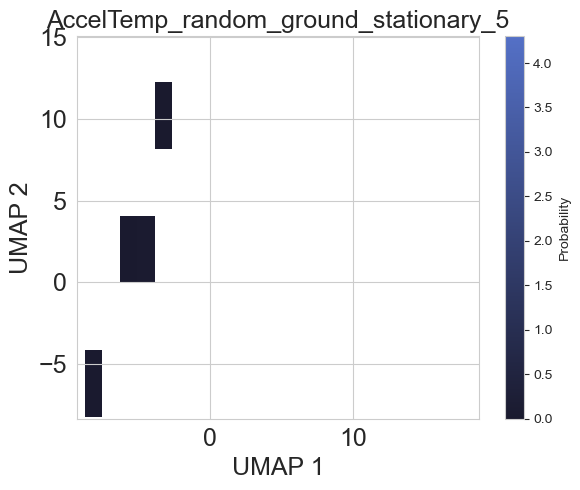

图像已保存至: D:/code/DeepView/deepview/calculate_results/data/umineko/figures/ScatterMap_AccelTemp_random_ground_stationary_5.png


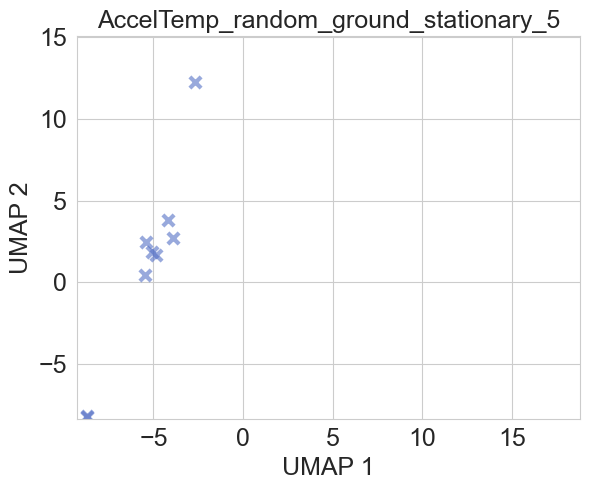

(3, 2)
0.06695755241718189


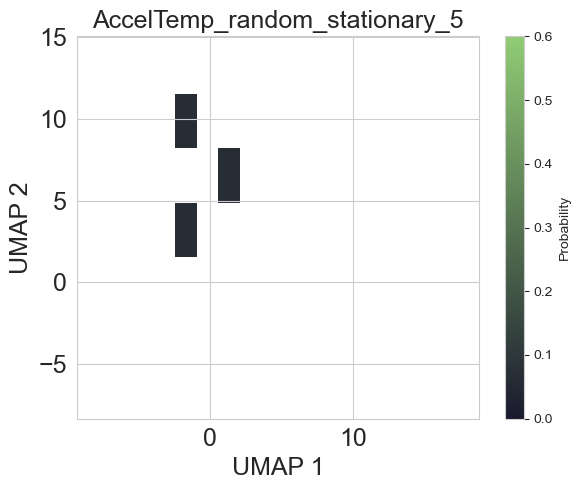

图像已保存至: D:/code/DeepView/deepview/calculate_results/data/umineko/figures/ScatterMap_AccelTemp_random_stationary_5.png


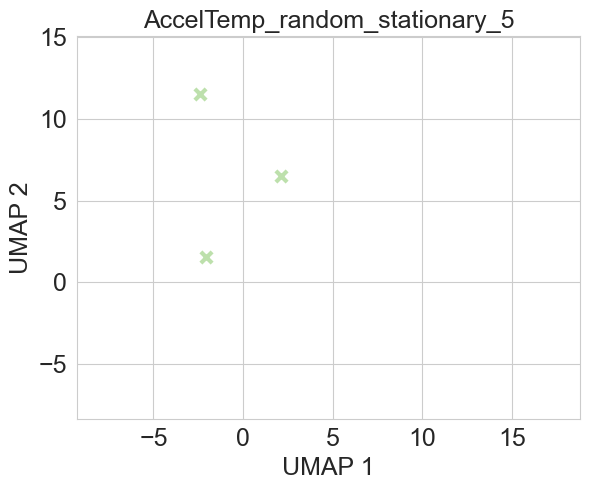

(1, 2)
1.0


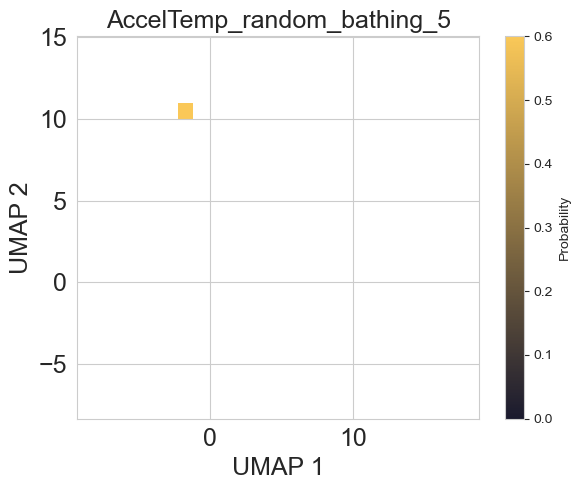

图像已保存至: D:/code/DeepView/deepview/calculate_results/data/umineko/figures/ScatterMap_AccelTemp_random_bathing_5.png


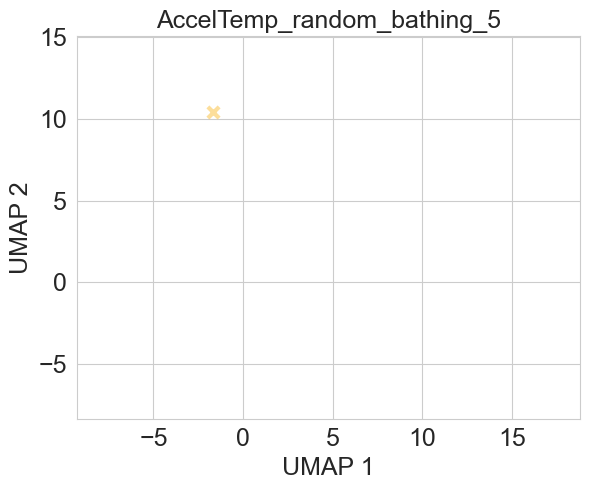

(44, 2)
0.02982035806739923


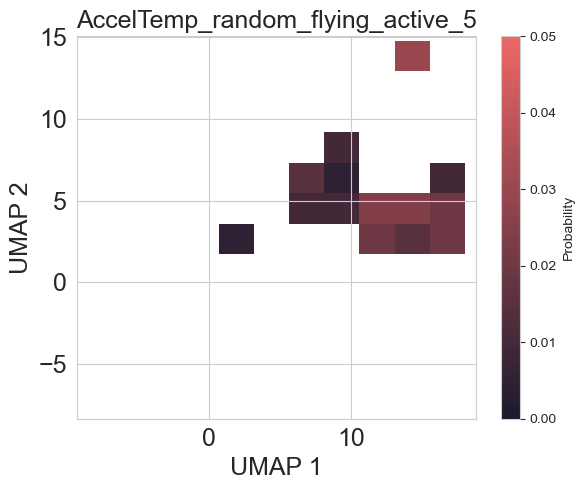

图像已保存至: D:/code/DeepView/deepview/calculate_results/data/umineko/figures/ScatterMap_AccelTemp_random_flying_active_5.png


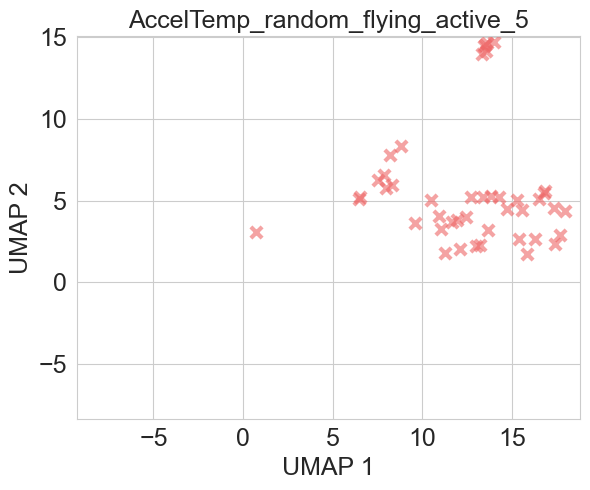

(2, 2)
1.1358410209214451


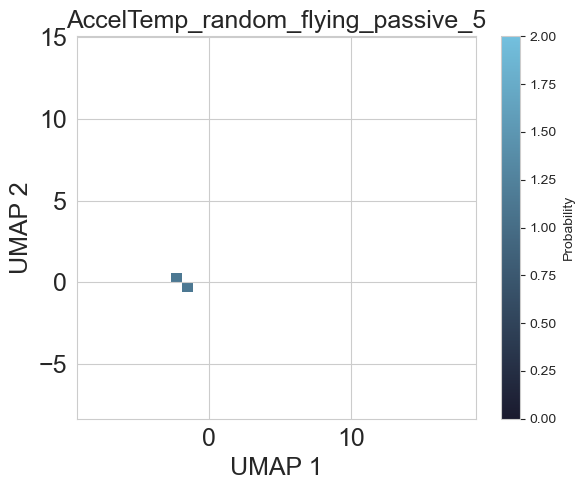

图像已保存至: D:/code/DeepView/deepview/calculate_results/data/umineko/figures/ScatterMap_AccelTemp_random_flying_passive_5.png


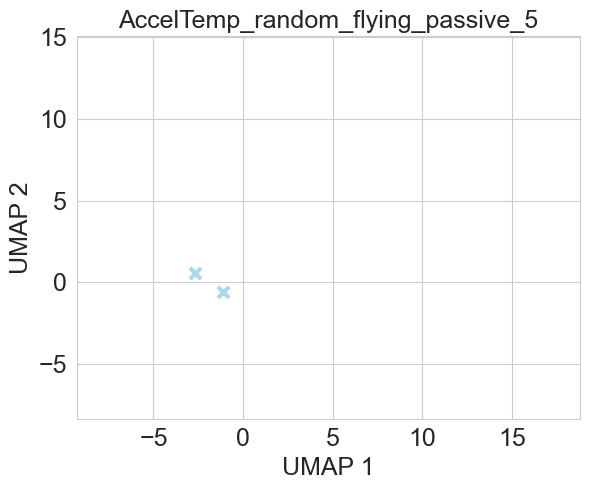

In [71]:
colorbar_max = [4.3, 0.6, 0.6, 0.05, 2]
# colorbar_max = [0.1, 1.2, 1.6, 0.04, 0.7]
for target_act in target_act_list:
    actstr = labeldict_findstr[target_act]

    selected_act_umap = data_umap[act_label_idx_list[target_act],:]
    print(selected_act_umap.shape)
    
    # 计算x和y轴的最大最小值
    x_min = np.min(data_umap[:, 0])
    x_max = np.max(data_umap[:, 0])
    y_min = np.min(data_umap[:, 1])
    y_max = np.max(data_umap[:, 1])

    figtitle = f'{sensor_type}_{sampling_method}_{actstr}_{iteration}'
    plot_umap_histogram(selected_act_umap, colorbar_max[int(target_act)], title=figtitle, xlim=(x_min, x_max), ylim=(y_min, y_max), actcolor=label_colors[target_act])
    plot_umap_scatter(selected_act_umap, title=figtitle, actcolor=label_colors[target_act], 
                      xlim=(x_min, x_max), ylim=(y_min, y_max), point_size=65, alpha=0.6)